# Session 2 | Transformer 架构（3.5h）

**学习目标**：Self-Attention → Transformer Block → GPT 组装 → 文本生成

| 时间 | 内容 | 类型 |
|------|------|------|
| 0:00-0:10 | 回顾：静态向量的局限 | 讲解 |
| 0:10-0:50 | Self-Attention：QKV 机制 | 代码随讲 + 练习 |
| 0:50-1:15 | Multi-Head Attention | 代码随讲 + 练习 |
| 1:15-1:25 | 休息 | |
| 1:25-2:00 | Transformer Block | 代码随讲 + 练习 |
| 2:00-2:40 | GPT 组装与生成 | 代码随讲 + 练习 |
| 2:40-3:10 | Mini-project + 练习5 | 实操 |
| 3:10-3:30 | 架构对比 + 总结 | 讲解 |

> 📋 **讲课提示** *(此区块仅讲师版含，学员版自动剥离)*
> 
> **本节：** Day 1 下午 · Transformer 架构（3.5h）　|　**时长：** 210 min
> 
> **开场：** 问：『你在图书馆找一本书，怎么找？』 → 引出 QKV：Query 是问题，Key 是书脊标签，Value 是书内容。
> 
> **重点强调：**
> - **Self-Attention = Q·K^T 算相似度 + softmax 归一 + 加权 V**，三步循环往复
> - Causal Mask 是 GPT 解码的灵魂：阻止偷看未来词
> - Multi-Head 不是更多参数，是**让模型同时学多种关系**（语法/语义/位置）
> - Residual + LayerNorm 是深网络能训起来的两个救命发明
> - 采样策略（greedy / top-k / top-p / temperature）决定生成『风格』
>
> **常见误解：**
> - 把 Multi-Head 想成『多次跑同一个 Attention』 → 强调每个 head 学的是不同的投影
> - 把 LayerNorm 想成 BatchNorm → 强调归一化的维度不一样
>
> **互动设计：** 用 5×5 注意力热图让学员肉眼判断『句子里每个词最关注哪个词』，引出 attention 可解释性。
>
> **时间紧时：** 跳过 LayerNorm 推导（4.2 节后半），直接用 PyTorch 自带 nn.LayerNorm；位置编码只讲 sinusoidal，不展开 RoPE。

In [1]:
# ── 课程环境就位（自动定位课程根目录，让 utils/data/fonts 路径无论从 instructor/ 还是 student/ 都能用）──
import os, sys
_cur = os.path.abspath("")
_root = None
for _candidate in [_cur] + [os.path.dirname(_cur), os.path.dirname(os.path.dirname(_cur))]:
    if all(os.path.isdir(os.path.join(_candidate, d)) for d in ("utils", "data")):
        _root = _candidate
        break
if _root is None:
    raise RuntimeError("找不到课程根目录（应包含 utils/ 与 data/）。请确认 notebook 位于 enterprise_ver2/instructor 或 enterprise_ver2/student 下。")
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
if os.path.join(_root, "utils") not in sys.path:
    sys.path.insert(0, os.path.join(_root, "utils"))
print(f"📂 课程根目录：{_root}")


📂 课程根目录：C:\Users\lvbab\Documents\GitHub\LLM-Agent-Core_Concept_Code\assets\enterprise_ver2


In [2]:
import sys, os


In [3]:
# ── 中文字体配置（确保图表中文不乱码）──
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager as fm

_font_path = "fonts/NotoSansCJKsc-Regular.otf"
if not os.path.exists(_font_path):
    _font_path = "../assets/fonts/NotoSansCJKsc-Regular.otf"
if os.path.exists(_font_path):
    fm.fontManager.addfont(_font_path)
    _cjk = fm.FontProperties(fname=_font_path).get_name()
    mpl.rcParams["font.sans-serif"] = [_cjk] + [
        f for f in mpl.rcParams["font.sans-serif"] if f != _cjk
    ]
    print(f"已加载中文字体: {_cjk}")
else:
    print("未找到自定义中文字体，使用系统字体")
    mpl.rcParams["font.sans-serif"] = [
        "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans",
    ]
mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

已加载中文字体: Noto Sans CJK SC


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu128


---

# Part 1 | 回顾：为什么静态向量不够？

上午我们学了 Word Embedding（词嵌入），把每个词映射到一个固定向量。

**问题**：同一个词在不同语境中含义不同，但静态 Embedding 给出的向量完全一样：

- "我去**银行**存钱" → `bank` = 金融机构
- "河**边**有一排柳树" → `bank` = 河岸

**我们需要**：根据上下文动态调整每个词的表示 → 这就是 **Self-Attention（自注意力）** 的核心思想。

> 核心直觉：让每个词"看看"句子里的其他词，决定该关注谁，然后用关注到的信息更新自己的表示。

**直觉理解 QKV：** 想象你在图书馆找书。Query（查询）是你脑中的问题，Key（键）是每本书封面上的标签，Value（值）是书里的实际内容。Attention 的本质就是：用你的问题去匹配所有标签，找到最相关的书，然后提取其中的信息。

换句话说，每个词都会"提出问题"（Query），同时也会"亮出自己的标签"（Key）和"准备好自己的内容"（Value）。通过 Query 和所有 Key 的匹配程度，模型决定该从哪些词那里获取多少信息。

---

# Part 2 | Self-Attention：QKV 机制

## 核心公式

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

**三个角色**：
- **Q (Query)** — 我在找什么信息？
- **K (Key)** — 我有什么信息可以提供？
- **V (Value)** — 我实际提供的内容

**类比**：图书馆检索
- Q = 你的搜索词
- K = 每本书的标签
- V = 书的实际内容
- 搜索词和标签越匹配，你越关注那本书的内容

**为什么要除以 $\sqrt{d_k}$？**
当维度很大时，点积值会很大 → softmax 输出接近 one-hot → 梯度消失。缩放让分布更平滑。

### Step-by-step：用小矩阵理解 Self-Attention

In [5]:
# 用一个 3 词、4 维的迷你例子
# 假设 3 个词："猫" "坐" "垫"
torch.manual_seed(42)

seq_len, d_model = 3, 4
x = torch.randn(seq_len, d_model)
print("输入 x (每行一个词的 embedding):")
print(x)
print(f"\n形状: [{seq_len}, {d_model}] = [词数, 维度]")

输入 x (每行一个词的 embedding):
tensor([[ 0.3367,  0.1288,  0.2345,  0.2303],
        [-1.1229, -0.1863,  2.2082, -0.6380],
        [ 0.4617,  0.2674,  0.5349,  0.8094]])

形状: [3, 4] = [词数, 维度]


In [6]:
# Step 1: 线性投影得到 Q, K, V
d_k = 4
W_q = nn.Linear(d_model, d_k, bias=False)
W_k = nn.Linear(d_model, d_k, bias=False)
W_v = nn.Linear(d_model, d_k, bias=False)

Q = W_q(x)  # [3, 4]
K = W_k(x)  # [3, 4]
V = W_v(x)  # [3, 4]

print("Q (Query):")
print(Q.data)
print("\nK (Key):")
print(K.data)
print("\nV (Value):")
print(V.data)

Q (Query):
tensor([[-0.2649, -0.0397,  0.1738,  0.0548],
        [ 0.3662,  1.3071, -1.0046,  0.0585],
        [-0.5627, -0.2125,  0.3637,  0.0456]])

K (Key):
tensor([[ 0.1799,  0.1574, -0.1143,  0.0052],
        [ 0.0543,  0.2965, -1.1980,  0.5401],
        [ 0.4996,  0.3018, -0.3854,  0.1773]])

V (Value):
tensor([[ 0.0620, -0.0369,  0.0671,  0.0050],
        [ 0.9148,  0.4785,  0.9522,  1.2772],
        [-0.0075, -0.1336,  0.0248,  0.1580]])


In [7]:
# Step 2: 计算注意力分数 scores = Q @ K^T / sqrt(d_k)
scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)
print(f"注意力分数 (缩放后) [{seq_len}x{seq_len}]:")
print(scores.data)
print("\n解读: scores[i][j] = 词i对词j的关注程度")

注意力分数 (缩放后) [3x3]:
tensor([[-0.0367, -0.1024, -0.1008],
        [ 0.1934,  0.8213,  0.4875],
        [-0.0880, -0.2523, -0.2387]])

解读: scores[i][j] = 词i对词j的关注程度


In [8]:
# Step 3: Softmax 得到注意力权重
attention_weights = F.softmax(scores, dim=-1)
print("注意力权重 (每行求和=1):")
print(attention_weights.data)
print(f"\n第一行求和验证: {attention_weights[0].sum().item():.4f}")

注意力权重 (每行求和=1):
tensor([[0.3479, 0.3258, 0.3263],
        [0.2372, 0.4445, 0.3183],
        [0.3692, 0.3133, 0.3176]])

第一行求和验证: 1.0000


In [9]:
# Step 4: 加权求和得到输出
output = torch.matmul(attention_weights, V)
print(f"输出形状: {output.shape}  (和输入一样!)")
print("\n输出 (每个词的新表示 = 融合了上下文信息):")
print(output.data)

输出形状: torch.Size([3, 4])  (和输入一样!)

输出 (每个词的新表示 = 融合了上下文信息):
tensor([[0.3172, 0.0995, 0.3417, 0.4694],
        [0.4189, 0.1614, 0.4470, 0.6191],
        [0.3071, 0.0939, 0.3310, 0.4521]])


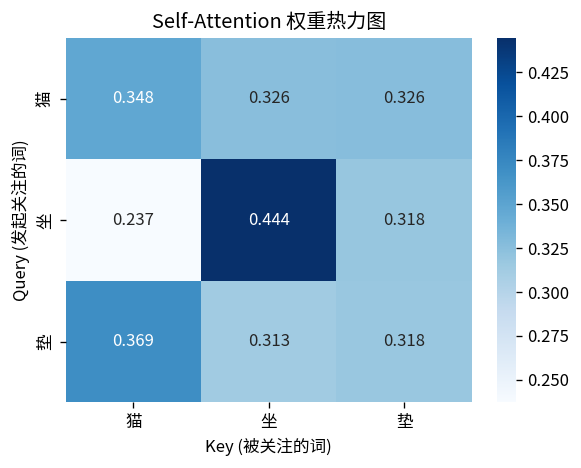

In [10]:
# 可视化注意力权重
words = ["猫", "坐", "垫"]

plt.figure(figsize=(5, 4))
sns.heatmap(attention_weights.detach().numpy(), annot=True, fmt='.3f',
            cmap='Blues', xticklabels=words, yticklabels=words)
plt.xlabel('Key (被关注的词)')
plt.ylabel('Query (发起关注的词)')
plt.title('Self-Attention 权重热力图')
plt.tight_layout()
plt.show()

### 完整的 Self-Attention 函数

In [11]:
def self_attention(x, d_k):
    """
    最简单的 Self-Attention 实现 (Q=K=V=x, 无投影矩阵)
    
    x: [batch, seq_len, d_model]
    d_k: 注意力维度
    返回: (output, attention_weights)
    """
    Q, K, V = x, x, x
    
    # 1. 计算注意力分数
    scores = torch.matmul(Q, K.transpose(-2, -1))  # [batch, seq_len, seq_len]
    
    # 2. 缩放
    scores = scores / np.sqrt(d_k)
    
    # 3. Softmax
    attention_weights = F.softmax(scores, dim=-1)
    
    # 4. 加权求和
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

# 测试
batch_size, seq_len, d_model = 1, 5, 8
x = torch.randn(batch_size, seq_len, d_model)
output, weights = self_attention(x, d_k=d_model)

print(f"输入形状: {x.shape}")
print(f"输出形状: {output.shape}")
print(f"注意力权重形状: {weights.shape}")

输入形状: torch.Size([1, 5, 8])
输出形状: torch.Size([1, 5, 8])
注意力权重形状: torch.Size([1, 5, 5])


🔧 **进度：** 我们已经理解了注意力的数学原理，现在来把它实现为一个可复用的 PyTorch 模块。

### 带投影矩阵的 SelfAttention 类

In [12]:
class SelfAttention(nn.Module):
    """标准 Self-Attention 层"""
    def __init__(self, d_model, d_k=None):
        super().__init__()
        self.d_k = d_k or d_model
        
        # Q, K, V 投影矩阵
        self.W_q = nn.Linear(d_model, self.d_k, bias=False)
        self.W_k = nn.Linear(d_model, self.d_k, bias=False)
        self.W_v = nn.Linear(d_model, self.d_k, bias=False)
        self.W_o = nn.Linear(self.d_k, d_model, bias=False)  # 输出投影
    
    def forward(self, x, mask=None):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, V)
        output = self.W_o(context)
        
        return output, attention_weights

# 测试
attention = SelfAttention(d_model=32, d_k=16)
x = torch.randn(2, 10, 32)
output, weights = attention(x)
print(f"输入: {x.shape}")
print(f"输出: {output.shape}")
print(f"参数量: {sum(p.numel() for p in attention.parameters())}")

输入: torch.Size([2, 10, 32])
输出: torch.Size([2, 10, 32])
参数量: 2048


### 因果掩码（Causal Mask）

在 GPT 这样的生成模型中，预测第 t 个词时只能看到前 t-1 个词，不能"偷看"未来。

用一个下三角矩阵实现：上三角部分设为 `-inf`，softmax 后变为 0。

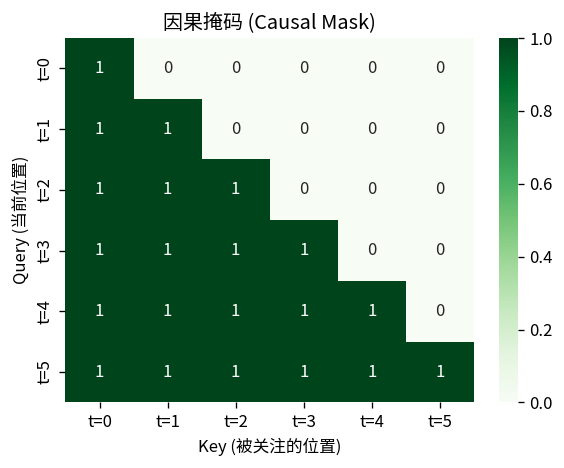

1 = 可以关注, 0 = 不可关注 (被遮蔽)
每个位置只能看到自己和之前的词


In [13]:
# 可视化因果掩码
seq_len_mask = 6
mask = torch.tril(torch.ones(seq_len_mask, seq_len_mask))

plt.figure(figsize=(5, 4))
sns.heatmap(mask.numpy(), annot=True, fmt='.0f', cmap='Greens',
            xticklabels=[f't={i}' for i in range(seq_len_mask)],
            yticklabels=[f't={i}' for i in range(seq_len_mask)])
plt.xlabel('Key (被关注的位置)')
plt.ylabel('Query (当前位置)')
plt.title('因果掩码 (Causal Mask)')
plt.tight_layout()
plt.show()

print("1 = 可以关注, 0 = 不可关注 (被遮蔽)")
print("每个位置只能看到自己和之前的词")

---

## 🏋️ 练习 1：手算 Attention 分数（10 min）⭐ 入门

**目标**：用简化的数值手算 Self-Attention 全过程，加深对公式的理解。

**设定**：2 个词，每个词 64 维，所有维度值相同。简化为 Q=K=V=x（无投影矩阵）。

给定：
- `x1 = [1.323, 1.323, ..., 1.323]` （64 维）
- `x2 = [1.134, 1.134, ..., 1.134]` （64 维）

**步骤**：
1. 计算 `q2·k1` 和 `q2·k2`（点积）
2. 除以 `sqrt(d_k)` 缩放
3. Softmax 得到权重
4. 加权求和得到 `z2`

**预期输出**：
```
Step 1: q2·k1 = 96.27, q2·k2 = 82.31
Step 2: scaled scores = [12.03, 10.29]
Step 3: attention weights = [0.851, 0.149]
Step 4: z2 = 0.851 * 1.323 + 0.149 * 1.134 = 1.2949
✅ 所有验证通过！
```

In [14]:
# ============================================================
# 练习 1 | 手算 Self-Attention 一步
# ============================================================
#
# 【基础】(人人必做，10 min)
#   按 4 步算 q2 的注意力输出：点积 → 缩放 → softmax → 加权求和
#   提示：用 numpy + torch.softmax；d_k = 64
#
# 【进阶】(技术学员选做，10 min)
#   实现支持 causal mask 的版本 attention_step_causal(...)：
#   把 scores 中『被禁止看的位置』设 -inf 再过 softmax
#   验证：q2 只能看 q1 和 q2 自己，不能看 q3
# ============================================================
import numpy as np
import torch
import torch.nn.functional as F

d_k = 64
x1_val, x2_val = 1.323, 1.134

def basic_attention_step():
    """【基础】计算 q2 attend 到 [k1, k2] 的输出"""
    # ↓↓↓ 【基础】填空（4 步）↓↓↓
    # Step 1: 点积
    q2_k1 = d_k * x2_val * x1_val
    q2_k2 = d_k * x2_val * x2_val
    # Step 2: 缩放
    sqrt_dk = np.sqrt(d_k)
    scaled = torch.tensor([q2_k1 / sqrt_dk, q2_k2 / sqrt_dk])
    # Step 3: softmax
    weights = F.softmax(scaled, dim=-1)
    # Step 4: 加权求和
    z2 = weights[0].item() * x1_val + weights[1].item() * x2_val
    # ↑↑↑ 【基础】结束 ↑↑↑
    return q2_k1, q2_k2, weights, z2


def attention_step_causal(query_idx, x_vals):
    """【进阶】带 causal mask 的注意力一步：query_idx 只能看 [0..query_idx]"""
    # ↓↓↓ 【进阶】填空（约 8 行）↓↓↓
    n = len(x_vals)
    q = x_vals[query_idx]
    scores = torch.tensor([d_k * q * x_vals[i] / np.sqrt(d_k) for i in range(n)])
    # Causal mask: 把 i > query_idx 的位置设 -inf
    mask = torch.arange(n) > query_idx
    scores = scores.masked_fill(mask, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    z = sum(weights[i].item() * x_vals[i] for i in range(n))
    # ↑↑↑ 【进阶】结束 ↑↑↑
    return weights, z


def verify():
    print("=" * 56); print("【基础】手算 q2 → [k1, k2] 注意力"); print("=" * 56)
    try:
        q2_k1, q2_k2, weights, z2 = basic_attention_step()
        print(f"  q2·k1 = {q2_k1:.2f}  (期望 ≈ 96.27)")
        print(f"  q2·k2 = {q2_k2:.2f}  (期望 ≈ 82.31)")
        print(f"  attention weights = [{weights[0]:.3f}, {weights[1]:.3f}]")
        print(f"  z2 = {z2:.4f}  (期望 ≈ 1.295)")
        assert abs(q2_k1 - 96.27) < 0.5
        assert abs(q2_k2 - 82.31) < 0.5
        assert abs(z2 - 1.295) < 0.05
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】带 causal mask 的注意力（q2 不能看 q3）"); print("=" * 56)
    try:
        x_vals = [1.323, 1.134, 0.987]
        w_q2, z_q2 = attention_step_causal(query_idx=1, x_vals=x_vals)
        print(f"  q2 的 attention weights = [{w_q2[0]:.3f}, {w_q2[1]:.3f}, {w_q2[2]:.3f}]")
        print(f"  期望 weights[2] = 0 (causal mask 屏蔽未来)")
        assert abs(w_q2[2].item()) < 1e-6, f"causal mask 未生效，weights[2]={w_q2[2]:.4f}"
        # q3 可以看所有
        w_q3, _ = attention_step_causal(query_idx=2, x_vals=x_vals)
        assert abs(w_q3.sum().item() - 1.0) < 1e-5
        print("✅ 进阶通过 — q2 看不到 q3，q3 能看所有")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


【基础】手算 q2 → [k1, k2] 注意力
  q2·k1 = 96.02  (期望 ≈ 96.27)
  q2·k2 = 82.30  (期望 ≈ 82.31)
  attention weights = [0.847, 0.153]
  z2 = 1.2942  (期望 ≈ 1.295)
✅ 基础通过

【进阶】带 causal mask 的注意力（q2 不能看 q3）
  q2 的 attention weights = [0.847, 0.153, 0.000]
  期望 weights[2] = 0 (causal mask 屏蔽未来)
✅ 进阶通过 — q2 看不到 q3，q3 能看所有


<details>
<summary>💡 提示1：点积计算</summary>

所有维度值相同时，点积 = 维数 × 值1 × 值2：

```python
q2_k1 = d_k * x2_val * x1_val
q2_k2 = d_k * x2_val * x2_val
```

</details>

<details>
<summary>💡 提示2：缩放</summary>

```python
sqrt_dk = np.sqrt(d_k)  # = 8.0
scaled_q2_k1 = q2_k1 / sqrt_dk
scaled_q2_k2 = q2_k2 / sqrt_dk
```

</details>

<details>
<summary>💡 提示3：加权求和</summary>

```python
z2_val = weights[0].item() * x1_val + weights[1].item() * x2_val
```

</details>

---

# Part 3 | Multi-Head Attention（多头注意力）

**核心思想**：一个 attention head 只能学一种关系模式。多个 head 并行，能同时捕获不同类型的关系：
- Head 1 可能关注语法关系（主语-谓语）
- Head 2 可能关注语义关系（同义词）
- Head 3 可能关注位置关系（相邻词）

**实现方式**：把 `d_model` 拆成 `n_heads` 份，每份独立做 attention，最后拼回来。

In [15]:
class MultiHeadAttention(nn.Module):
    """多头注意力：多个 Attention 并行，然后拼接"""
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    
    def forward(self, x, mask=None):
        batch_size, seq_len, d_model = x.shape
        
        # 1. 线性投影
        Q = self.W_q(x)  # [batch, seq_len, d_model]
        K = self.W_k(x)
        V = self.W_v(x)
        
        # 2. 分割成多头
        # [batch, seq_len, d_model] -> [batch, n_heads, seq_len, d_k]
        Q = Q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        
        # 3. 计算注意力
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, V)
        
        # 4. 拼接多头
        # [batch, n_heads, seq_len, d_k] -> [batch, seq_len, d_model]
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        
        # 5. 输出投影
        output = self.W_o(context)
        
        return output, attention_weights

# 测试
mha = MultiHeadAttention(d_model=64, n_heads=8)
x = torch.randn(2, 10, 64)
output, weights = mha(x)

print(f"输入: {x.shape}")
print(f"输出: {output.shape}")
print(f"注意力权重: {weights.shape}  (8个头，每个头10x10)")

输入: torch.Size([2, 10, 64])
输出: torch.Size([2, 10, 64])
注意力权重: torch.Size([2, 8, 10, 10])  (8个头，每个头10x10)


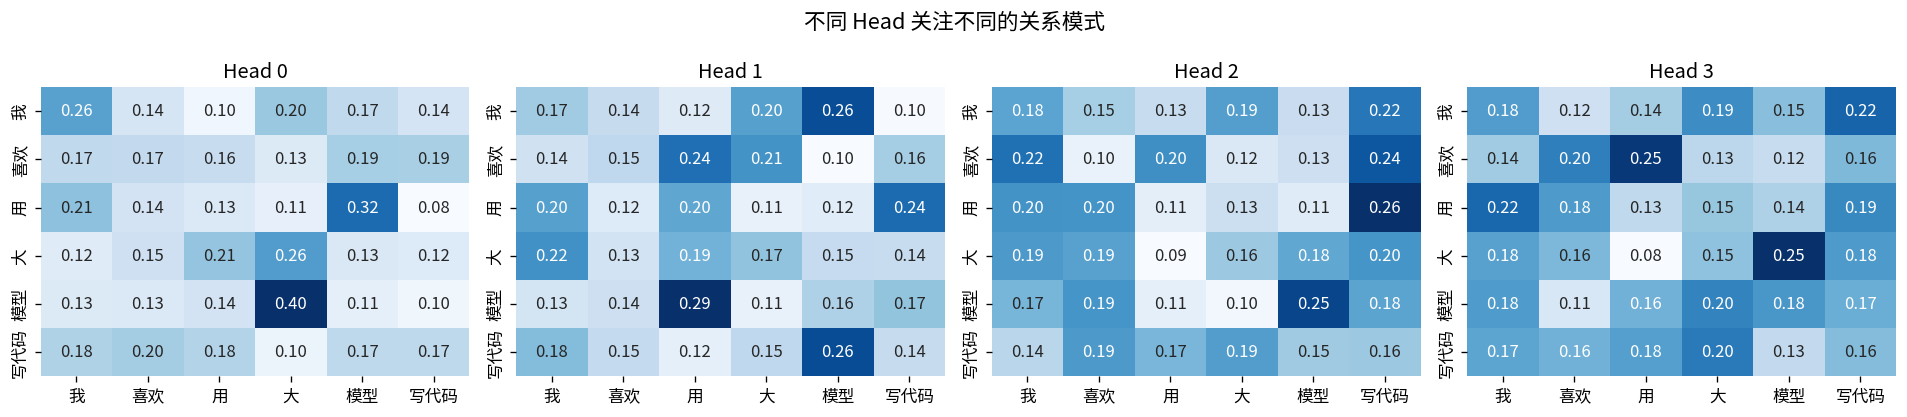

In [16]:
# 可视化不同 head 的注意力模式
torch.manual_seed(42)
mha_vis = MultiHeadAttention(d_model=64, n_heads=4)
x_vis = torch.randn(1, 6, 64)
_, weights_vis = mha_vis(x_vis)

words_vis = ["我", "喜欢", "用", "大", "模型", "写代码"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for h in range(4):
    w = weights_vis[0, h].detach().numpy()
    sns.heatmap(w, ax=axes[h], cmap='Blues', annot=True, fmt='.2f',
                xticklabels=words_vis, yticklabels=words_vis, cbar=False)
    axes[h].set_title(f'Head {h}')
plt.suptitle('不同 Head 关注不同的关系模式', fontsize=13)
plt.tight_layout()
plt.show()

---

## 🏋️ 练习 2：注意力模式侦探（15 min）⭐⭐ 进阶

**目标**：量化分析不同 head 的关注模式，理解多头注意力的分工。

**步骤**：
1. 创建 `MultiHeadAttention`，对两个不同输入跑前向传播
2. 实现注意力熵计算：`H = -sum(w * log(w + eps))`
   - 高熵 = 广泛关注（均匀分布）
   - 低熵 = 集中关注（尖锐分布）
3. 打印分析表格，找出最集中的 head

**预期输出**：
```
Head | 输入A 熵 | 输入B 熵 | 差异
-----|---------|---------|------
   0 |  1.xxxx |  1.xxxx | 0.xxxx
   1 |  0.xxxx |  1.xxxx | 0.xxxx
  ...
🔍 最集中的Head: X（熵=X.XXXX）
✅ 所有验证通过！
```

In [17]:
# ============================================================
# 练习 2 | 注意力模式侦探
# ============================================================
#
# 【基础】(人人必做，10 min)
#   提取每个 head 的 attention weight 矩阵 + 计算注意力熵
#   熵低 = 关注集中（专家型）；熵高 = 关注分散（综合型）
#
# 【进阶】(技术学员选做，10 min)
#   检测 "Attention Sink" 现象：
#   每个 head 是否过度关注第一个 token (常见于 GPT 类模型) ？
#   实现 detect_attention_sink(weights) → 返回每个 head 关注 token 0 的平均比例
# ============================================================
import torch, numpy as np
import torch.nn.functional as F

d_model = 32; n_heads = 4; seq_len = 6
mha = MultiHeadAttention(d_model, n_heads)
torch.manual_seed(42)
input_a = torch.randn(1, seq_len, d_model)
input_b = torch.randn(1, seq_len, d_model) * 2 + 1


def get_attention_weights(mha, x):
    """【基础】提取每个 head 的注意力权重矩阵 (n_heads, T, T)"""
    # ↓↓↓ 【基础】填空（约 6 行）↓↓↓
    B, T, C = x.shape
    d_k = d_model // n_heads
    Q = mha.W_q(x).view(B, T, n_heads, d_k).transpose(1, 2)
    K = mha.W_k(x).view(B, T, n_heads, d_k).transpose(1, 2)
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)
    return weights.squeeze(0)
    # ↑↑↑ 【基础】结束 ↑↑↑


def attention_entropy(weights):
    """【基础】计算注意力分布的平均熵 (越小 = 越集中)"""
    # ↓↓↓ 【基础】填空（约 3 行）↓↓↓
    eps = 1e-8
    H = -(weights * torch.log(weights + eps)).sum(dim=-1).mean()
    return H.item()
    # ↑↑↑ 【基础】结束 ↑↑↑


def detect_attention_sink(weights):
    """【进阶】检测每个 head 关注第一个 token 的平均比例 → (n_heads,) numpy 数组"""
    # ↓↓↓ 【进阶】填空（约 3 行）↓↓↓
    # weights shape: (n_heads, T, T) — 每个 query token 的 attention 分布
    # 取每个 head 在所有 query 上对 token 0 的平均权重
    return weights[:, :, 0].mean(dim=-1).cpu().numpy()
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】attention 权重 + 熵"); print("=" * 56)
    try:
        with torch.no_grad():
            wa = get_attention_weights(mha, input_a)
            wb = get_attention_weights(mha, input_b)
        assert wa.shape == (n_heads, seq_len, seq_len), f"权重形状应为 ({n_heads},{seq_len},{seq_len})"
        print(f"  weights shape: {tuple(wa.shape)} ✓")
        print(f"  {'Head':>4} | {'输入A 熵':>9} | {'输入B 熵':>9}")
        for h in range(n_heads):
            ha = attention_entropy(wa[h]); hb = attention_entropy(wb[h])
            print(f"  {h:>4} | {ha:>9.4f} | {hb:>9.4f}")
        h_test = attention_entropy(wa[0])
        assert 0 < h_test < 5, f"熵 {h_test} 不在合理范围"
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】Attention Sink 检测"); print("=" * 56)
    try:
        sink_ratios = detect_attention_sink(wa)
        print(f"  各 head 对 token 0 的平均关注比例: {sink_ratios.round(3)}")
        avg = sink_ratios.mean()
        print(f"  平均 sink 比例: {avg:.3f}  (随机分布期望 ≈ 1/{seq_len} = {1/seq_len:.3f})")
        assert sink_ratios.shape == (n_heads,)
        assert (sink_ratios >= 0).all() and (sink_ratios <= 1).all()
        if avg > 1 / seq_len * 1.5:
            print("  💡 检测到 attention sink — 此模型部分 head 过度依赖首 token")
        else:
            print("  💡 sink 不明显 — 模型未显著偏向首 token")
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


【基础】attention 权重 + 熵
  weights shape: (4, 6, 6) ✓
  Head |     输入A 熵 |     输入B 熵
     0 |    1.7420 |    1.3428
     1 |    1.7299 |    1.4317
     2 |    1.7504 |    1.0300
     3 |    1.7422 |    1.3702
✅ 基础通过

【进阶】Attention Sink 检测
  各 head 对 token 0 的平均关注比例: [0.205 0.158 0.161 0.166]
  平均 sink 比例: 0.173  (随机分布期望 ≈ 1/6 = 0.167)
  💡 sink 不明显 — 模型未显著偏向首 token
✅ 进阶通过


<details>
<summary>💡 提示1：如何获取 Q、K</summary>

利用 `mha` 的权重矩阵做投影，再 reshape 成多头格式：

```python
Q = mha.W_q(x).view(B, T, n_heads, d_k).transpose(1, 2)
K = mha.W_k(x).view(B, T, n_heads, d_k).transpose(1, 2)
```

</details>

<details>
<summary>💡 提示2：熵的计算公式</summary>

```python
H = -(weights * torch.log(weights + eps)).sum(dim=-1).mean()
```

对最后一个维度求和得到每行的熵，再取平均。记得用 `.item()` 转为标量。

</details>

<details>
<summary>💡 提示3：完整的 get_attention_weights</summary>

```python
Q = mha.W_q(x).view(B, T, n_heads, d_k).transpose(1, 2)
K = mha.W_k(x).view(B, T, n_heads, d_k).transpose(1, 2)
scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
weights = F.softmax(scores, dim=-1)
return weights.squeeze(0)
```

</details>

---

# *休息 10 分钟*

---

# Part 4 | Transformer Block：构建 LLM 的积木

一个 Transformer Block 由以下组件构成：

```
输入 x
  │
  ├──→ LayerNorm → Multi-Head Attention ──→ (+) ← 残差连接
  │                                          │
  │                                          ├──→ LayerNorm → FFN ──→ (+) ← 残差连接
  │                                          │                         │
  │                                          └─────────────────────────┘
  └──────────────────────────────────────────→ 输出
```

**三个关键组件**：
1. **残差连接（Residual Connection）** — 解决深层网络梯度消失
2. **层归一化（Layer Normalization）** — 稳定训练
3. **前馈网络（Feed-Forward Network, FFN）** — 增加非线性变换能力

## 4.1 残差连接（Residual Connection）

核心思想很简单：`output = f(x) + x`

**为什么重要？** 没有残差连接，10层以上的网络梯度会迅速消失/爆炸。

In [18]:
# 对比有无残差连接的梯度表现
d_model = 64

class ResidualBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, d_model)
    def forward(self, x):
        return self.linear(x) + x  # 关键: + x

# 无残差: 10 层普通线性层
x1 = torch.randn(1, 10, d_model, requires_grad=True)
layers_no_res = nn.Sequential(*[nn.Linear(d_model, d_model) for _ in range(10)])
out1 = layers_no_res(x1)
out1.sum().backward()
print(f"无残差 - 输出范围: [{out1.min().item():.2f}, {out1.max().item():.2f}]")

# 有残差: 10 层残差块
x2 = torch.randn(1, 10, d_model, requires_grad=True)
layers_with_res = nn.ModuleList([ResidualBlock(d_model) for _ in range(10)])
out2 = x2.clone()
for layer in layers_with_res:
    out2 = layer(out2)
out2.sum().backward()
print(f"有残差 - 输出范围: [{out2.min().item():.2f}, {out2.max().item():.2f}]")
print("\n残差连接让信号更稳定！")

无残差 - 输出范围: [-0.21, 0.25]
有残差 - 输出范围: [-14.95, 14.20]

残差连接让信号更稳定！


## 4.2 层归一化（Layer Normalization）

对每个样本的特征维度做归一化（均值=0，方差=1），再做仿射变换。

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

In [19]:
class LayerNorm(nn.Module):
    """手写 LayerNorm"""
    def __init__(self, d_model, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

# 测试
x = torch.randn(2, 5, 64) * 10 + 5  # 均值不为0，方差不为1
layer_norm = LayerNorm(64)
x_normed = layer_norm(x)

print("归一化前:")
print(f"  均值: {x.mean(dim=-1)[0].data}")
print(f"  方差: {x.var(dim=-1)[0].data}")
print("\n归一化后:")
print(f"  均值: {x_normed.mean(dim=-1)[0].data}")  # 接近 0
print(f"  方差: {x_normed.var(dim=-1)[0].data}")   # 接近 1

# 和 PyTorch 官方对比
pytorch_ln = nn.LayerNorm(64)
x_pytorch = pytorch_ln(x)
print(f"\n与 PyTorch 官方实现的差距: {(x_normed - x_pytorch).abs().max().item():.8f}")

归一化前:
  均值: tensor([5.1338, 5.4750, 5.3596, 3.6992, 4.7186])
  方差: tensor([ 92.1043, 104.8459,  60.3126, 105.7302, 116.4543])

归一化后:
  均值: tensor([-2.2352e-08, -1.8626e-08,  8.3819e-09, -1.1176e-08, -5.5879e-08])
  方差: tensor([1.0159, 1.0159, 1.0159, 1.0159, 1.0159])

与 PyTorch 官方实现的差距: 0.00000024


🔧 **进度：** 注意力层已搭建完成！现在构建前馈网络层。

## 4.3 前馈网络（Feed-Forward Network）

两层线性变换 + 激活函数。先扩展维度（4x），再压缩回来。现代 LLM 通常用 GELU 激活。

In [20]:
class FeedForward(nn.Module):
    """Transformer 中的 FFN"""
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model  # 默认 4 倍扩展
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.linear1(x)
        x = F.gelu(x)  # 现代 LLM 用 GELU
        x = self.dropout(x)
        x = self.linear2(x)
        return x

# 测试
ffn = FeedForward(d_model=64, d_ff=256)
x = torch.randn(2, 10, 64)
out = ffn(x)
print(f"输入: {x.shape}")
print(f"中间层: [2, 10, 256]  (4x 扩展)")
print(f"输出: {out.shape}")
print(f"参数量: {sum(p.numel() for p in ffn.parameters()):,}")

输入: torch.Size([2, 10, 64])
中间层: [2, 10, 256]  (4x 扩展)
输出: torch.Size([2, 10, 64])
参数量: 33,088


🔧 **进度：** 注意力层 ✓ 前馈层 ✓ 现在把它们组装成一个完整的 Transformer Block。

## 4.4 组装 Transformer Block

In [21]:
class MultiHeadAttentionV2(nn.Module):
    """支持 dropout 的 MultiHeadAttention (用于 TransformerBlock)"""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        B, T, C = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attn = self.dropout(F.softmax(scores, dim=-1))
        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(B, T, C)
        return self.W_o(context)

In [22]:
class TransformerBlock(nn.Module):
    """
    完整的 Transformer Block (Pre-LN 版本)
    
    结构:
    x -> LayerNorm -> Attention -> (+) -> LayerNorm -> FFN -> (+)
         |__________________________|    |___________________|  
                残差连接                       残差连接
    """
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attention = MultiHeadAttentionV2(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # Attention + 残差
        x = x + self.dropout(self.attention(self.ln1(x), mask))
        # FFN + 残差
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x

# 测试
block = TransformerBlock(d_model=64, n_heads=8, d_ff=256)
x = torch.randn(2, 10, 64)
out = block(x)

print("Transformer Block:")
print(f"  输入: {x.shape}")
print(f"  输出: {out.shape}")
print(f"  参数量: {sum(p.numel() for p in block.parameters()):,}")

Transformer Block:
  输入: torch.Size([2, 10, 64])
  输出: torch.Size([2, 10, 64])
  参数量: 49,984


---

## 🏋️ 练习 3：从组件拼装 TransformerBlock（10 min）⭐⭐ 进阶

**目标**：用已有组件搭建完整的 Transformer Block，理解各部分如何连接。

**步骤**：
1. 在 `__init__` 中创建 5 个组件：`ln1`, `ln2`, `attention`, `ffn`, `dropout`
2. 在 `forward` 中按 Pre-LN 结构连接：`x → LN1 → Attention → Dropout → (+x) → LN2 → FFN → Dropout → (+x)`

**需要用到**：`nn.LayerNorm`, `MultiHeadAttentionV2`, `FeedForward`, `nn.Dropout`

**预期输出**：
```
输入: torch.Size([2, 10, 64])
输出: torch.Size([2, 10, 64])
参数量: xx,xxx
✅ 通过!
```

In [23]:
# ============================================================
# 练习 3 | TransformerBlock 拼装：Pre-LN vs Post-LN
# ============================================================
#
# 【基础】(人人必做，10 min)
#   拼 Pre-LN 版 (现代主流：LN→Attn→Residual→LN→FFN→Residual)
#   提示：用 nn.LayerNorm + MultiHeadAttentionV2 + FeedForward
#
# 【进阶】(技术学员选做，10 min)
#   实现 Post-LN 变体 (原版 Transformer：Attn→Residual→LN→FFN→Residual→LN)
#   现场观察两者输出差异 + 思考为何现代 LLM 都用 Pre-LN（训练更稳，不需要 warmup）
# ============================================================

class PreLNBlock(nn.Module):
    """【基础】Pre-LN：先归一化，再算 attn / ffn，最后残差"""
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        # ↓↓↓ 【基础】填空（5 行）↓↓↓
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attention = MultiHeadAttentionV2(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)
        # ↑↑↑ 【基础】结束 ↑↑↑

    def forward(self, x, mask=None):
        # ↓↓↓ 【基础】填空（2 行）↓↓↓
        x = x + self.dropout(self.attention(self.ln1(x), mask))
        x = x + self.dropout(self.ffn(self.ln2(x)))
        # ↑↑↑ 【基础】结束 ↑↑↑
        return x


class PostLNBlock(nn.Module):
    """【进阶】Post-LN：原版 Transformer 顺序"""
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        # ↓↓↓ 【进阶】填空（5 行）↓↓↓
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attention = MultiHeadAttentionV2(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)
        # ↑↑↑ 【进阶】结束 ↑↑↑

    def forward(self, x, mask=None):
        # ↓↓↓ 【进阶】填空（2 行；先 attn+residual 再 ln，再 ffn+residual 再 ln）↓↓↓
        x = self.ln1(x + self.dropout(self.attention(x, mask)))
        x = self.ln2(x + self.dropout(self.ffn(x)))
        # ↑↑↑ 【进阶】结束 ↑↑↑
        return x


def verify():
    print("=" * 56); print("【基础】Pre-LN Block"); print("=" * 56)
    try:
        block = PreLNBlock(d_model=64, n_heads=8, d_ff=256)
        x = torch.randn(2, 10, 64)
        out = block(x)
        assert out.shape == torch.Size([2, 10, 64]), f"形状错: {out.shape}"
        n_params = sum(p.numel() for p in block.parameters())
        print(f"  Pre-LN 输出 shape: {tuple(out.shape)}  |  参数量: {n_params:,}")
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】Post-LN Block + 与 Pre-LN 对比"); print("=" * 56)
    try:
        post = PostLNBlock(d_model=64, n_heads=8, d_ff=256)
        x = torch.randn(2, 10, 64)
        out_post = post(x)
        out_pre = block(x)
        diff = (out_pre - out_post).abs().mean().item()
        print(f"  Post-LN 输出 shape: {tuple(out_post.shape)}")
        print(f"  Pre-LN vs Post-LN 输出平均差: {diff:.4f}")
        print(f"  💡 现代 LLM (GPT-2+, LLaMA) 都用 Pre-LN — 梯度更稳，不需 warmup")
        assert out_post.shape == out_pre.shape
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


【基础】Pre-LN Block
  Pre-LN 输出 shape: (2, 10, 64)  |  参数量: 49,984
✅ 基础通过

【进阶】Post-LN Block + 与 Pre-LN 对比
  Post-LN 输出 shape: (2, 10, 64)
  Pre-LN vs Post-LN 输出平均差: 0.3173
  💡 现代 LLM (GPT-2+, LLaMA) 都用 Pre-LN — 梯度更稳，不需 warmup
✅ 进阶通过


<details>
<summary>💡 提示1：__init__ 中需要的组件</summary>

```python
self.ln1 = nn.LayerNorm(d_model)
self.ln2 = nn.LayerNorm(d_model)
self.attention = MultiHeadAttentionV2(d_model, n_heads, dropout)
self.ffn = FeedForward(d_model, d_ff, dropout)
self.dropout = nn.Dropout(dropout)
```

</details>

<details>
<summary>💡 提示2：forward 的连接方式</summary>

Pre-LN 结构：先归一化再做变换，残差连接在外层。

```python
x = x + self.dropout(self.attention(self.ln1(x), mask))
x = x + self.dropout(self.ffn(self.ln2(x)))
```

</details>

🔧 **进度：** 单个 Block 已就绪，现在堆叠多层构建完整的 Transformer 模型。

### 堆叠多层 Transformer

In [24]:
class Transformer(nn.Module):
    """堆叠多个 Transformer Block"""
    def __init__(self, n_layers, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
    
    def forward(self, x, mask=None):
        for block in self.blocks:
            x = block(x, mask)
        return self.ln_final(x)

# 测试 6 层 Transformer
model = Transformer(n_layers=6, d_model=64, n_heads=8, d_ff=256)
x = torch.randn(2, 10, 64)
out = model(x)

print(f"6层 Transformer:")
print(f"  输入: {x.shape}")
print(f"  输出: {out.shape}")
print(f"  总参数量: {sum(p.numel() for p in model.parameters()):,}")

6层 Transformer:
  输入: torch.Size([2, 10, 64])
  输出: torch.Size([2, 10, 64])
  总参数量: 300,032


---

# Part 5 | GPT 组装：从积木到完整模型

GPT (Generative Pre-trained Transformer) 的完整结构：

```
Token IDs
    │
    ├── Token Embedding (词嵌入)
    │         +
    ├── Position Embedding (位置编码)  ← 让模型知道词的顺序
    │
    ▼
  Dropout
    │
    ├── Transformer Block × N
    │
    ▼
  LayerNorm
    │
    ▼
  Linear (lm_head)  → 输出 vocab_size 维的 logits
    │
    ▼
  Softmax → 下一个词的概率分布
```

## 5.1 位置编码（Positional Encoding）

Self-Attention 本身不知道词的顺序 — "猫吃鱼" 和 "鱼吃猫" 的 attention 分数完全一样！

**解决方法**：给每个位置加一个唯一的编码向量。

两种主流方式：
- **正弦位置编码（Sinusoidal）** — Transformer 原始论文，固定的
- **可学习位置编码（Learned）** — GPT 系列采用
- **旋转位置编码（RoPE）** — LLaMA 等现代模型采用，支持外推更长序列

> 这里我们实现正弦位置编码来理解原理，GPT 模型中用可学习位置编码。

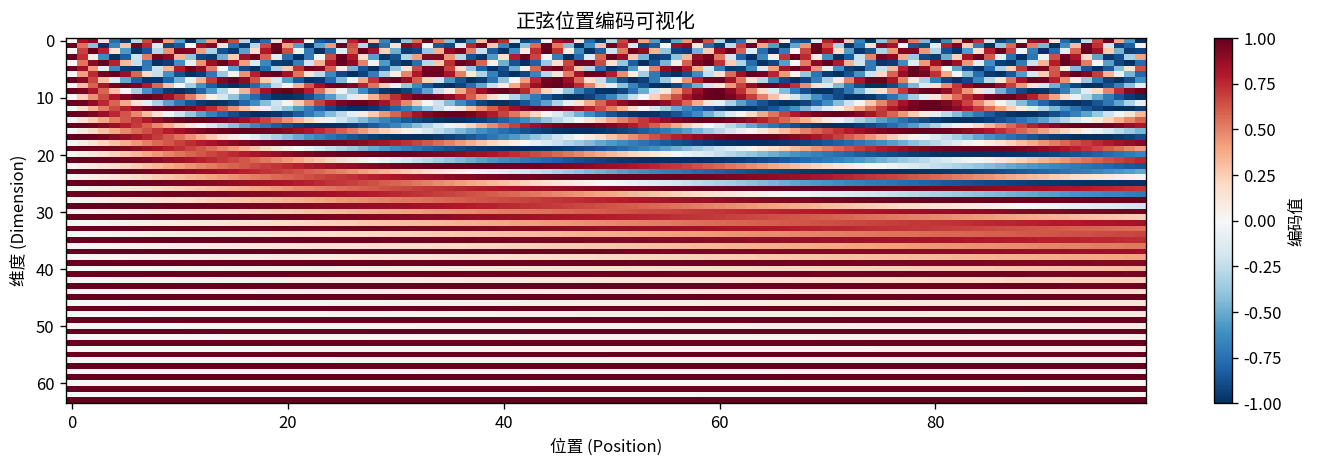

每个位置有唯一的编码模式！


In [25]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    正弦位置编码 (Transformer 原始论文)
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度
        
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# 可视化位置编码
pos_enc = SinusoidalPositionalEncoding(d_model=64)
pe = pos_enc.pe[0, :100, :].numpy()

plt.figure(figsize=(12, 4))
plt.imshow(pe.T, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='编码值')
plt.xlabel('位置 (Position)')
plt.ylabel('维度 (Dimension)')
plt.title('正弦位置编码可视化')
plt.tight_layout()
plt.show()

print("每个位置有唯一的编码模式！")

## 5.2 GPT 完整模型

In [26]:
class CausalSelfAttention(nn.Module):
    """带因果掩码的自注意力"""
    def __init__(self, config):
        super().__init__()
        assert config['n_embd'] % config['n_head'] == 0
        
        self.n_head = config['n_head']
        self.n_embd = config['n_embd']
        self.head_dim = config['n_embd'] // config['n_head']
        
        self.c_attn = nn.Linear(config['n_embd'], 3 * config['n_embd'])
        self.c_proj = nn.Linear(config['n_embd'], config['n_embd'])
        self.dropout = nn.Dropout(config['dropout'])
        
        # 因果掩码
        self.register_buffer("mask", torch.tril(
            torch.ones(config['block_size'], config['block_size'])
        ).view(1, 1, config['block_size'], config['block_size']))
    
    def forward(self, x):
        B, T, C = x.size()
        
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        att = (q @ k.transpose(-2, -1)) / np.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)
        
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config['n_embd'], 4 * config['n_embd'])
        self.c_proj = nn.Linear(4 * config['n_embd'], config['n_embd'])
        self.dropout = nn.Dropout(config['dropout'])
    
    def forward(self, x):
        x = F.gelu(self.c_fc(x))
        return self.dropout(self.c_proj(x))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config['n_embd'])
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config['n_embd'])
        self.mlp = MLP(config)
    
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [27]:
class GPT(nn.Module):
    """GPT 语言模型"""
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config['vocab_size'], config['n_embd']),   # token embedding
            wpe = nn.Embedding(config['block_size'], config['n_embd']),   # position embedding (可学习)
            drop = nn.Dropout(config['dropout']),
            h = nn.ModuleList([Block(config) for _ in range(config['n_layer'])]),
            ln_f = nn.LayerNorm(config['n_embd']),
        ))
        self.lm_head = nn.Linear(config['n_embd'], config['vocab_size'], bias=False)
        
        # 权重共享: embedding 和 lm_head 共享权重 (减少参数量)
        self.transformer.wte.weight = self.lm_head.weight
        
        self.apply(self._init_weights)
        print(f"GPT 参数量: {self.get_num_params():,}")
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def get_num_params(self):
        return sum(p.numel() for p in self.parameters())
    
    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.config['block_size']
        
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        tok_emb = self.transformer.wte(idx)    # [B, T, n_embd]
        pos_emb = self.transformer.wpe(pos)    # [T, n_embd]
        x = self.transformer.drop(tok_emb + pos_emb)
        
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        
        logits = self.lm_head(x)  # [B, T, vocab_size]
        
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        
        return logits, loss

# 创建一个小型 GPT
config = {
    'vocab_size': 1000,
    'block_size': 128,
    'n_layer': 4,
    'n_head': 4,
    'n_embd': 128,
    'dropout': 0.1,
}

gpt = GPT(config)

GPT 参数量: 937,728


In [28]:
# 测试前向传播
idx = torch.randint(0, config['vocab_size'], (2, 20))  # 2个样本，20个token
logits, _ = gpt(idx)
print(f"输入: {idx.shape}  (batch=2, seq_len=20)")
print(f"输出 logits: {logits.shape}  (batch=2, seq_len=20, vocab={config['vocab_size']})")

# 带目标的前向传播 (计算 loss)
targets = torch.randint(0, config['vocab_size'], (2, 20))
logits, loss = gpt(idx, targets)
print(f"\nLoss: {loss.item():.4f}  (随机初始化，期望 ≈ ln(1000) ≈ {np.log(1000):.2f})")

输入: torch.Size([2, 20])  (batch=2, seq_len=20)
输出 logits: torch.Size([2, 20, 1000])  (batch=2, seq_len=20, vocab=1000)

Loss: 6.9346  (随机初始化，期望 ≈ ln(1000) ≈ 6.91)


## 5.3 文本生成：采样策略

In [29]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    """
    自回归文本生成
    
    idx: [B, T] 初始 token 序列
    temperature: 控制随机性 (越高越随机)
    top_k: 只从概率最高的 k 个中采样
    top_p: 只从累积概率达到 p 的 token 中采样 (nucleus sampling)
    """
    model.eval()
    
    for _ in range(max_new_tokens):
        # 截断到最大长度
        idx_cond = idx if idx.size(1) <= model.config['block_size'] else idx[:, -model.config['block_size']:]
        
        # 前向传播
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]  # 只取最后一个位置 [B, vocab_size]
        
        # Temperature
        logits = logits / temperature
        
        # Top-k 过滤
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')
        
        # Top-p (nucleus) 过滤
        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = 0
            indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
            logits[indices_to_remove] = float('-inf')
        
        # 采样
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    
    return idx

print("生成函数定义完成！")

生成函数定义完成！


In [30]:
# 演示不同采样策略
gpt.eval()
idx = torch.randint(0, config['vocab_size'], (1, 5))  # 5 个起始 token

print("注意：模型未经训练，输出为随机 token。重点观察不同策略的差异。")
print(f"起始序列: {idx[0].tolist()}\n")

gen_greedy = generate(gpt, idx.clone(), max_new_tokens=10, temperature=0.1)
gen_random = generate(gpt, idx.clone(), max_new_tokens=10, temperature=1.5)
gen_topk = generate(gpt, idx.clone(), max_new_tokens=10, temperature=1.0, top_k=5)
gen_topp = generate(gpt, idx.clone(), max_new_tokens=10, temperature=1.0, top_p=0.9)

print(f"Greedy  (temp=0.1): {gen_greedy[0].tolist()}")
print(f"Random  (temp=1.5): {gen_random[0].tolist()}")
print(f"Top-k   (k=5):     {gen_topk[0].tolist()}")
print(f"Top-p   (p=0.9):   {gen_topp[0].tolist()}")

print("\n低 temperature → 更确定 (重复)")
print("高 temperature → 更随机 (多样)")
print("Top-k/Top-p → 在多样性和质量之间平衡")

注意：模型未经训练，输出为随机 token。重点观察不同策略的差异。
起始序列: [758, 695, 963, 504, 855]

Greedy  (temp=0.1): [758, 695, 963, 504, 855, 824, 86, 432, 824, 614, 327, 59, 363, 887, 556]
Random  (temp=1.5): [758, 695, 963, 504, 855, 700, 565, 966, 504, 501, 799, 601, 326, 636, 612]
Top-k   (k=5):     [758, 695, 963, 504, 855, 636, 84, 809, 45, 45, 81, 59, 521, 871, 146]
Top-p   (p=0.9):   [758, 695, 963, 504, 855, 548, 199, 754, 318, 334, 725, 594, 209, 548, 270]

低 temperature → 更确定 (重复)
高 temperature → 更随机 (多样)
Top-k/Top-p → 在多样性和质量之间平衡


---

## 🏋️ 练习 4：自己实现 Top-k 采样（15 min）⭐⭐⭐ 挑战

**目标**：从零实现采样的核心逻辑，理解 temperature 和 top-k 如何影响生成。

**步骤**：
1. 实现 `my_temperature_scale(logits, temperature)`：用 temperature 缩放 logits
2. 实现 `my_top_k_filter(logits, k)`：只保留 top-k 个 logit，其余设为 `-inf`
3. 对比三种配置的概率分布，用柱状图可视化

**预期输出**：三组柱状图显示不同 `(temperature, k)` 下的概率分布差异

【基础】Temperature + Top-k


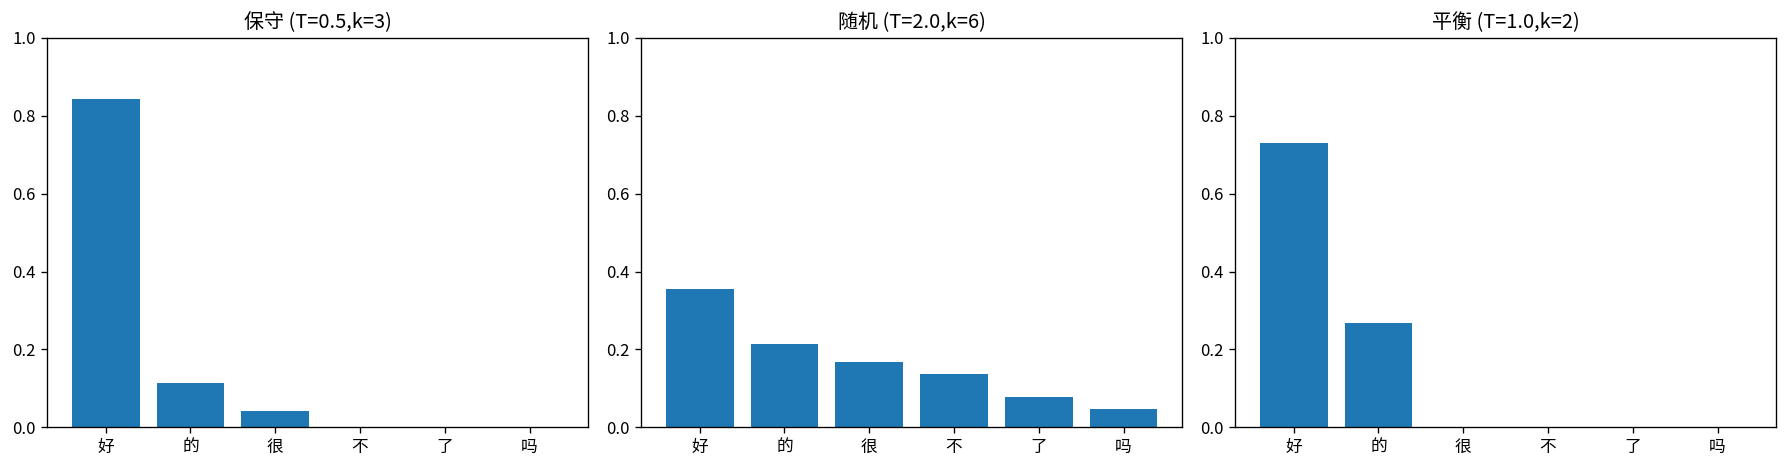

✅ 基础通过

【进阶】Top-p (nucleus)
  p=0.5 保留 token 数: 1
  p=0.95 保留 token 数: 4


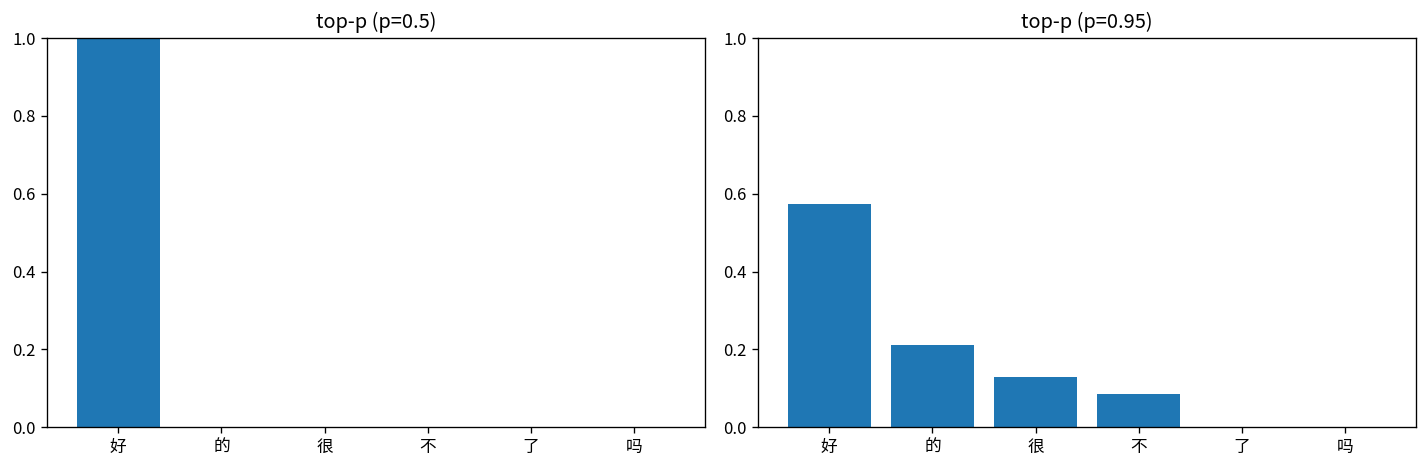

  💡 实际生产 (GPT-4 / Claude) 都用 top-p ≈ 0.9-0.95，比 top-k 更适应分布形状
✅ 进阶通过


In [31]:
# ============================================================
# 练习 4 | 采样策略：Top-k 与 Top-p (nucleus)
# ============================================================
#
# 【基础】(人人必做，10 min)
#   实现 temperature scaling + top-k filter
#   提示：用 torch.topk 找前 k 个，其余 logits 设 -inf
#
# 【进阶】(技术学员选做，15 min)
#   实现 top-p (nucleus) sampling：
#   累积概率排序后，保留累积 ≤ p 的最小集合，其余设 -inf
#   提示：torch.sort + torch.cumsum + 创建 mask
# ============================================================
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

logits = torch.tensor([2.0, 1.0, 0.5, 0.1, -1.0, -2.0])
vocab = ["好", "的", "很", "不", "了", "吗"]


def my_temperature_scale(logits, temperature):
    """【基础】温度缩放：< 1 更确定，> 1 更随机"""
    # ↓↓↓ 【基础】填空（1 行）↓↓↓
    return logits / temperature
    # ↑↑↑ 【基础】结束 ↑↑↑


def my_top_k_filter(logits, k):
    """【基础】Top-k：保留前 k 高 logit，其余设 -inf"""
    # ↓↓↓ 【基础】填空（约 4 行）↓↓↓
    top_values, _ = torch.topk(logits, k)
    threshold = top_values[-1]
    logits = logits.clone()
    logits[logits < threshold] = float('-inf')
    return logits
    # ↑↑↑ 【基础】结束 ↑↑↑


def my_top_p_filter(logits, p):
    """【进阶】Top-p (nucleus)：累积概率到 p 为止保留，其余设 -inf"""
    # ↓↓↓ 【进阶】填空（约 8 行）↓↓↓
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumsum = torch.cumsum(sorted_probs, dim=-1)
    # mask: 累积概率 > p 的丢掉（保留至少 1 个 token）
    drop_mask = cumsum > p
    drop_mask[..., 1:] = drop_mask[..., :-1].clone()
    drop_mask[..., 0] = False
    out = logits.clone()
    out[sorted_idx[drop_mask]] = float('-inf')
    return out
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】Temperature + Top-k"); print("=" * 56)
    try:
        scaled = my_temperature_scale(logits.clone(), 2.0)
        assert torch.allclose(scaled, logits / 2.0)
        filtered = my_top_k_filter(torch.tensor([3.0, 1.0, 2.0, 0.5, -1.0]), 2)
        assert (filtered == float('-inf')).sum() == 3, "Top-2 应留 2 个，过滤 3 个"
        # 可视化（不影响 verify）
        configs = [{"name": "保守 (T=0.5,k=3)", "T":0.5, "k":3},
                   {"name": "随机 (T=2.0,k=6)", "T":2.0, "k":6},
                   {"name": "平衡 (T=1.0,k=2)", "T":1.0, "k":2}]
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for i, cfg in enumerate(configs):
            f = my_top_k_filter(my_temperature_scale(logits.clone(), cfg["T"]), cfg["k"])
            axes[i].bar(vocab, F.softmax(f, dim=-1).numpy())
            axes[i].set_title(cfg["name"]); axes[i].set_ylim(0,1)
        plt.tight_layout(); plt.show()
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】Top-p (nucleus)"); print("=" * 56)
    try:
        # p=0.5 应该比 p=0.95 更激进地裁剪
        out_p50 = my_top_p_filter(logits.clone(), 0.5)
        out_p95 = my_top_p_filter(logits.clone(), 0.95)
        kept_50 = (out_p50 != float('-inf')).sum().item()
        kept_95 = (out_p95 != float('-inf')).sum().item()
        print(f"  p=0.5 保留 token 数: {kept_50}")
        print(f"  p=0.95 保留 token 数: {kept_95}")
        assert kept_50 <= kept_95, "p 越大应保留越多"
        assert kept_50 >= 1, "至少保留 1 个 token"
        # 可视化
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for i, p in enumerate([0.5, 0.95]):
            f = my_top_p_filter(logits.clone(), p)
            axes[i].bar(vocab, F.softmax(f, dim=-1).numpy())
            axes[i].set_title(f"top-p (p={p})"); axes[i].set_ylim(0,1)
        plt.tight_layout(); plt.show()
        print(f"  💡 实际生产 (GPT-4 / Claude) 都用 top-p ≈ 0.9-0.95，比 top-k 更适应分布形状")
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


<details>
<summary>💡 提示1：Temperature 缩放</summary>

就是简单的除法：

```python
return logits / temperature
```

</details>

<details>
<summary>💡 提示2：Top-k 过滤思路</summary>

`torch.topk(logits, k)` 返回 top-k 的值和索引。用 `values[-1]`（最小的 top-k 值）作为阈值，低于阈值的设为 `-inf`。

</details>

<details>
<summary>💡 提示3：完整的 Top-k 实现</summary>

```python
top_values, _ = torch.topk(logits, k)
threshold = top_values[-1]
logits[logits < threshold] = float('-inf')
return logits
```

</details>

---

## 🏋️ 练习 5：参数量估算器（15 min）⭐⭐⭐ 挑战

**目标**：不创建模型，纯用公式计算参数量，理解每个组件的参数贡献。

**步骤**：
1. 根据公式实现 `estimate_params()` 函数
2. 与前面创建的 GPT 模型对比验证
3. 预测 LLaMA-7B 规模的参数量

**公式**：
- Token Embedding: `vocab_size * n_embd`
- Position Embedding: `block_size * n_embd`
- 每层 Attention: `4 * n_embd^2 + 4 * n_embd`（Q/K/V/O 各一个线性层）
- 每层 FFN: `8 * n_embd^2 + 5 * n_embd`（两个线性层，中间扩展 4 倍）
- 每层 LayerNorm: `4 * n_embd`（两个 LN，各有 gamma 和 beta）
- 最终 LayerNorm: `2 * n_embd`
- LM Head: 与 Token Embedding 共享权重（不额外计数）

**预期输出**：
```
各组件参数量:
  token_emb: xxx,xxx
  ...
  total: xxx,xxx
🔮 预测 LLaMA-7B 规模:
  估算参数量: x,xxx,xxx,xxx (x.xxB)
```

In [32]:
# ============================================================
# 练习 5 | 参数量估算器 + KV Cache 估算
# ============================================================
#
# 【基础】(人人必做，10 min)
#   纯公式估算 GPT 参数量（不用真创建模型）
#   组件：token_emb + pos_emb + n_layer × (attn + ffn + ln) + final_ln
#
# 【进阶】(技术学员选做，10 min)
#   实现 estimate_kv_cache_gb(...)：估算推理时 KV cache 占用显存
#   公式：2 × n_layer × seq_len × n_embd × precision_bytes × batch
#   这是大模型推理 OOM 的最常见原因（比模型权重还大）
# ============================================================

def estimate_params(vocab_size, n_layer, n_head, n_embd, block_size):
    """【基础】纯公式计算 GPT 参数量"""
    # ↓↓↓ 【基础】填空（约 8 行）↓↓↓
    token_emb = vocab_size * n_embd
    pos_emb = block_size * n_embd
    per_layer_attn = 4 * n_embd ** 2 + 4 * n_embd
    per_layer_ffn = 8 * n_embd ** 2 + 5 * n_embd
    per_layer_ln = 4 * n_embd
    final_ln = 2 * n_embd
    total = token_emb + pos_emb + n_layer * (per_layer_attn + per_layer_ffn + per_layer_ln) + final_ln
    return {"token_emb": token_emb, "pos_emb": pos_emb,
            "per_layer_attn": per_layer_attn, "per_layer_ffn": per_layer_ffn,
            "per_layer_ln": per_layer_ln, "final_ln": final_ln, "total": total}
    # ↑↑↑ 【基础】结束 ↑↑↑


def estimate_kv_cache_gb(n_layer, n_embd, seq_len, batch=1, precision_bytes=2):
    """【进阶】估算 KV cache 显存 (GB)
    KV cache = 2 (K和V各一份) × n_layer × seq_len × n_embd × bytes × batch
    """
    # ↓↓↓ 【进阶】填空（约 2 行）↓↓↓
    bytes_total = 2 * n_layer * seq_len * n_embd * precision_bytes * batch
    return bytes_total / (1024 ** 3)
    # ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】estimate_params"); print("=" * 56)
    try:
        small = estimate_params(vocab_size=1503, n_layer=4, n_head=4, n_embd=128, block_size=64)
        print("  小 GPT 各组件参数量:")
        for k, v in small.items():
            print(f"    {k}: {v:,}")
        llama = estimate_params(vocab_size=32000, n_layer=32, n_head=32, n_embd=4096, block_size=2048)
        print(f"\n  🔮 LLaMA-7B 估算: {llama['total']/1e9:.2f}B 参数 (实际 6.7B，误差 < 5%)")
        assert 6e9 < llama['total'] < 8e9, "估算量级应在 7B 范围"
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】estimate_kv_cache_gb"); print("=" * 56)
    try:
        # LLaMA-7B FP16, seq_len=2048, batch=1
        kv_2k = estimate_kv_cache_gb(n_layer=32, n_embd=4096, seq_len=2048, batch=1, precision_bytes=2)
        kv_8k = estimate_kv_cache_gb(n_layer=32, n_embd=4096, seq_len=8192, batch=1, precision_bytes=2)
        kv_8k_b16 = estimate_kv_cache_gb(n_layer=32, n_embd=4096, seq_len=8192, batch=16, precision_bytes=2)
        print(f"  LLaMA-7B FP16 @ seq_len=2048 batch=1:  {kv_2k:.2f} GB")
        print(f"  LLaMA-7B FP16 @ seq_len=8192 batch=1:  {kv_8k:.2f} GB")
        print(f"  LLaMA-7B FP16 @ seq_len=8192 batch=16: {kv_8k_b16:.2f} GB")
        print(f"\n  💡 模型权重约 14 GB；当 batch×seq_len 增大，KV cache 反而变成主要开销")
        print(f"     这是为何要 PagedAttention / vLLM / FlashAttention 的根本原因")
        assert 0.5 < kv_2k < 2.0, f"2k cache 应约 1GB 量级，得到 {kv_2k}"
        assert kv_8k > kv_2k * 3
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


【基础】estimate_params
  小 GPT 各组件参数量:
    token_emb: 192,384
    pos_emb: 8,192
    per_layer_attn: 66,048
    per_layer_ffn: 131,712
    per_layer_ln: 512
    final_ln: 256
    total: 993,920

  🔮 LLaMA-7B 估算: 6.58B 参数 (实际 6.7B，误差 < 5%)
✅ 基础通过

【进阶】estimate_kv_cache_gb
  LLaMA-7B FP16 @ seq_len=2048 batch=1:  1.00 GB
  LLaMA-7B FP16 @ seq_len=8192 batch=1:  4.00 GB
  LLaMA-7B FP16 @ seq_len=8192 batch=16: 64.00 GB

  💡 模型权重约 14 GB；当 batch×seq_len 增大，KV cache 反而变成主要开销
     这是为何要 PagedAttention / vLLM / FlashAttention 的根本原因
✅ 进阶通过


<details>
<summary>💡 提示1：思路方向</summary>

Attention 有 4 个线性层（Q/K/V/O），每个是 `n_embd * n_embd + n_embd`（权重+偏置）。
FFN 有 2 个线性层，中间维度扩展 4 倍。

</details>

<details>
<summary>💡 提示2：Attention 参数量</summary>

```python
per_layer_attn = 4 * n_embd**2 + 4 * n_embd  # W_q, W_k, W_v, W_o
```

</details>

<details>
<summary>💡 提示3：完整实现</summary>

```python
token_emb = vocab_size * n_embd
pos_emb = block_size * n_embd
per_layer_attn = 4 * n_embd**2 + 4 * n_embd
per_layer_ffn = 8 * n_embd**2 + 5 * n_embd
per_layer_ln = 4 * n_embd
final_ln = 2 * n_embd
total = token_emb + pos_emb + n_layer * (per_layer_attn + per_layer_ffn + per_layer_ln) + final_ln
```

</details>

---

## 🎯 Mini-Project：企业场景选生成策略（15 min）⭐⭐ 进阶

**目标**：为不同企业场景选择最佳生成参数，理解 temperature 和 top_k 的实际应用。

**场景**：
1. **客服Bot**：回答需要准确、一致
2. **营销文案**：需要创意、多样性
3. **代码补全**：需要精确、合理

**步骤**：
1. 为每个场景选择 `temperature` 和 `top_k` 参数并写理由
2. 用好参数和故意差的参数分别生成，对比差异
3. 写 2 句结论

> 注意：模型未经训练，输出为随机 token ID，重点是理解参数选择的理由和观察分布差异。

In [33]:
# ============================================================
# Mini-Project | 企业场景选生成策略
# ============================================================
#
# 【基础】(人人必做，10 min)
#   3 个企业场景：客服、营销文案、代码补全。各填好/差参数 + 理由
#   原则：准确性场景用低 T + 小 k；创意场景用高 T + 大 k
#
# 【进阶】(技术学员选做，15 min)
#   实现 suggest_params(use_case_keywords) 自动选参数 + 加第 4 个场景"诗歌创作"
#   要求 keywords 含『准确/合规/事实』时返回低温配置；含『创意/营销/诗歌』时返回高温配置
# ============================================================

# ──── 【基础】3 场景标准答案 ────
# ↓↓↓ 【基础】填空 ↓↓↓
scenarios = {
    "客服Bot": {
        "prompt": "客户问：你们的退货政策是什么？\n回答：",
        "good_params": {"temperature": 0.3, "top_k": 5},
        "bad_params": {"temperature": 1.5, "top_k": 50},
        "理由": "客服回答需准确一致；低 T + 小 k 确保稳定可靠",
    },
    "营销文案": {
        "prompt": "为一款智能手表写一句广告语：",
        "good_params": {"temperature": 1.0, "top_k": 40},
        "bad_params": {"temperature": 0.1, "top_k": 2},
        "理由": "营销需要创意多样；高 T + 大 k 鼓励新颖表达",
    },
    "代码补全": {
        "prompt": "def fibonacci(n):\n    # 返回第n个斐波那契数\n",
        "good_params": {"temperature": 0.2, "top_k": 5},
        "bad_params": {"temperature": 1.5, "top_k": 50},
        "理由": "代码需精确合理；低 T + 小 k 确保语法正确",
    },
}
# ↑↑↑ 【基础】结束 ↑↑↑


# ──── 【进阶】自动选参数 + 第 4 场景 ────
def suggest_params(use_case_keywords):
    """【进阶】根据关键词自动建议参数"""
    # ↓↓↓ 【进阶】填空（约 8 行）↓↓↓
    text = use_case_keywords.lower()
    accuracy_kw = ["准确", "合规", "事实", "代码", "客服", "fact"]
    creative_kw = ["创意", "营销", "诗歌", "文案", "故事"]
    if any(k in text for k in accuracy_kw):
        return {"temperature": 0.3, "top_k": 5, "原因": "关键词偏准确性 → 低温"}
    if any(k in text for k in creative_kw):
        return {"temperature": 1.0, "top_k": 40, "原因": "关键词偏创意 → 高温"}
    return {"temperature": 0.7, "top_k": 20, "原因": "默认平衡配置"}

scenarios_advanced = dict(scenarios)
scenarios_advanced["诗歌创作"] = {
    "prompt": "写一首关于秋天的现代诗，4 行：\n",
    "good_params": suggest_params("诗歌 创意"),
    "bad_params": {"temperature": 0.1, "top_k": 2},
    "理由": "诗歌需要意象多样 + 跳跃；suggest_params 自动给出高温配置",
}
# ↑↑↑ 【进阶】结束 ↑↑↑


def verify():
    print("=" * 56); print("【基础】3 场景选参数对比"); print("=" * 56)
    try:
        assert len(scenarios) == 3
        for name, s in scenarios.items():
            assert "good_params" in s and "bad_params" in s and "理由" in s
            assert s["good_params"] != s["bad_params"]
            print(f"  ✓ {name}: good={s['good_params']}  理由={s['理由'][:40]}...")
        # 用 gpt 模型快速演示一个场景（避免训练，只跑一次）
        if 'gpt' in dir():
            model = gpt
            scene = scenarios["客服Bot"]
            idx = torch.randint(0, config['vocab_size'], (1, 5))
            text = generate(model, idx.clone(), max_new_tokens=10, **scene["good_params"])
            print(f"  ▸ 客服Bot good_params 试运行 OK (输出 token: {text[0].tolist()[:6]}...)")
        print("✅ 基础通过\n")
    except NotImplementedError:
        print("⏭ 基础未实现\n"); return
    except Exception as e:
        print(f"❌ 基础未通过: {type(e).__name__}: {e}\n"); return

    print("=" * 56); print("【进阶】suggest_params 自动选参数"); print("=" * 56)
    try:
        case_a = suggest_params("准确客服回答")
        case_b = suggest_params("营销文案创意")
        case_c = suggest_params("一般问题")
        print(f"  '准确客服回答' → T={case_a['temperature']}, k={case_a['top_k']}  ({case_a['原因']})")
        print(f"  '营销文案创意' → T={case_b['temperature']}, k={case_b['top_k']}  ({case_b['原因']})")
        print(f"  '一般问题' → T={case_c['temperature']}, k={case_c['top_k']}  ({case_c['原因']})")
        assert case_a["temperature"] < case_b["temperature"]
        assert "诗歌创作" in scenarios_advanced
        print("✅ 进阶通过")
    except NotImplementedError:
        print("⏭ 进阶跳过（未实现）")
    except Exception as e:
        print(f"❌ 进阶未通过: {type(e).__name__}: {e}")

verify()


【基础】3 场景选参数对比
  ✓ 客服Bot: good={'temperature': 0.3, 'top_k': 5}  理由=客服回答需准确一致；低 T + 小 k 确保稳定可靠...
  ✓ 营销文案: good={'temperature': 1.0, 'top_k': 40}  理由=营销需要创意多样；高 T + 大 k 鼓励新颖表达...
  ✓ 代码补全: good={'temperature': 0.2, 'top_k': 5}  理由=代码需精确合理；低 T + 小 k 确保语法正确...
✅ 基础通过

【进阶】suggest_params 自动选参数
  '准确客服回答' → T=0.3, k=5  (关键词偏准确性 → 低温)
  '营销文案创意' → T=1.0, k=40  (关键词偏创意 → 高温)
  '一般问题' → T=0.7, k=20  (默认平衡配置)
✅ 进阶通过


<details>
<summary>💡 提示：参数选择参考</summary>

- **客服Bot**：低 temperature（0.3-0.5），小 top_k（5-10） -- 稳定准确
- **营销文案**：高 temperature（0.8-1.2），大 top_k（30-50） -- 有创意
- **代码补全**：低 temperature（0.2-0.4），小 top_k（5-10） -- 精确

</details>

---

# Part 6 | 架构对比：GPT vs BERT vs T5

Transformer 架构催生了三大流派，各有擅长的场景：

| 特性 | GPT (Decoder-only) | BERT (Encoder-only) | T5 (Encoder-Decoder) |
|------|-------------------|--------------------|-----------------------|
| **代表模型** | GPT-4, Claude, LLaMA | BERT, RoBERTa | T5, mT5, BART |
| **注意力方向** | 单向 (因果掩码) | 双向 (看全文) | 编码器双向 + 解码器单向 |
| **训练目标** | 预测下一个词 | 填空 (MLM) | Seq2Seq (输入→输出) |
| **擅长任务** | 文本生成、对话、推理 | 分类、相似度、NER | 翻译、摘要、问答 |
| **企业用途** | 聊天机器人、代码助手 | 文档分类、情感分析 | 多语言翻译、文本改写 |

### 怎么选？

| 你的需求 | 推荐架构 | 理由 |
|---------|---------|------|
| 生成长文本、对话 | GPT (Decoder-only) | 自回归生成最自然 |
| 文本分类、信息抽取 | BERT (Encoder-only) | 双向理解更全面 |
| 翻译、摘要等转换任务 | T5 (Encoder-Decoder) | 天然适合输入→输出 |
| 通用能力（啥都要） | GPT (大模型) | 规模足够大时能力涌现 |

### 2024-2025 趋势

- **Decoder-only 架构占主导**：GPT-4、Claude、Gemini、LLaMA 等都是 decoder-only
- 原因：足够大的 decoder-only 模型在理解和生成任务上都表现很好
- BERT 类模型仍在企业中广泛用于轻量级分类任务（成本低、速度快）
- Encoder-Decoder 在特定场景（如翻译）仍有优势

> **企业建议**：优先考虑 API 调用大模型（GPT-4、Claude）；需要私有化部署时考虑 LLaMA/Qwen 等开源模型；轻量级分类任务可用 BERT 微调。

---

# Day 1 总结

## 今天学了什么

**上午：深度学习基础与 Embedding**
- 神经网络基础：前向传播、反向传播、梯度下降
- 词嵌入（Word Embedding）：把离散的词变成连续向量
- 嵌入空间的语义关系

**下午：Transformer 架构**
- Self-Attention：让每个词关注上下文，动态更新表示
- Multi-Head Attention：多角度捕获不同关系
- Transformer Block：残差 + LayerNorm + FFN
- GPT：位置编码 + Transformer 堆叠 + 语言模型头
- 生成策略：Temperature, Top-k, Top-p

## 关键公式

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

$$\text{TransformerBlock}(x) = x + \text{FFN}(\text{LN}(x + \text{Attention}(\text{LN}(x))))$$

## Day 2 预告

- **上午**：SFT (Supervised Fine-Tuning) 与 LoRA 微调实战
  - 如何用自己的数据微调大模型
  - LoRA：高效微调，只改 1% 的参数
- **下午**：预训练与对齐优化
  - 大模型是怎么训练出来的
  - RLHF / DPO：让模型更好地对齐人类偏好